# DINOv2 Feature Extraction Demo
Loads scan scores → detects segments → extracts DINOv2 features → inspects vectors.

In [ ]:
import sys
import os
import time
import logging
sys.path.append('..')
os.chdir('..')  # run from project root so data/ paths resolve correctly

import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

from phase2.scanner import load_scores, detect_segments
from phase2.extractor import load_dinov2, extract_video, load_features

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(name)s: %(message)s',
    datefmt='%H:%M:%S',
)

## 1. Load scan scores and detect segments

In [2]:
VIDEO_ID   = 'LNEaa_cNf9M'
VIDEO_PATH = f'../data/videos/{VIDEO_ID}.mp4'
THRESHOLD  = 0.6

timestamps, scores = load_scores(VIDEO_ID)
segments = detect_segments(timestamps, scores, threshold=THRESHOLD, min_duration=5.0)

print(f'Video   : {VIDEO_ID}')
print(f'Segments: {len(segments)}')
total_sec = sum(e - s for s, e in segments)
print(f'Total octopus footage: {total_sec:.0f}s')

Video   : LNEaa_cNf9M
Segments: 18
Total octopus footage: 178s


## 2. Load DINOv2

In [3]:
model, transform, device = load_dinov2()
print(f'Device: {device}')

12:52:10 [INFO] phase2.extractor: Loading DINOv2 (dinov2_vitb14) on cpu ...


Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /Users/siddharthraj/.cache/torch/hub/main.zip


/Users/siddharthraj/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/siddharthraj/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/siddharthraj/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
12:52:11 [INFO] dinov2: using MLP layer as FFN


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /Users/siddharthraj/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:04<00:00, 85.8MB/s] 
12:52:16 [INFO] phase2.extractor: DINOv2 loaded in 6.4s


Device: cpu


## 3. Extract features

In [4]:
t0 = time.perf_counter()

out_path = extract_video(VIDEO_PATH, VIDEO_ID, segments, model, transform, device)

elapsed = time.perf_counter() - t0
print(f'\nWall time : {elapsed:.1f}s')
print(f'Per segment: {elapsed / len(segments) * 1000:.0f}ms')

12:52:16 [INFO] phase2.extractor: Extracting features for LNEaa_cNf9M  (18 segments) ...
12:52:17 [INFO] phase2.extractor:   [1/18]  12.0–18.0s  →  16 frames  (1.0s)
12:52:18 [INFO] phase2.extractor:   [2/18]  28.0–46.0s  →  16 frames  (1.1s)
12:52:19 [INFO] phase2.extractor:   [3/18]  55.0–60.0s  →  16 frames  (0.9s)
12:52:20 [INFO] phase2.extractor:   [4/18]  61.0–66.0s  →  16 frames  (0.9s)
12:52:21 [INFO] phase2.extractor:   [5/18]  92.0–101.0s  →  16 frames  (1.0s)
12:52:22 [INFO] phase2.extractor:   [6/18]  114.0–132.0s  →  16 frames  (1.0s)
12:52:23 [INFO] phase2.extractor:   [7/18]  153.0–160.0s  →  16 frames  (1.1s)
12:52:24 [INFO] phase2.extractor:   [8/18]  168.0–173.0s  →  16 frames  (1.0s)
12:52:25 [INFO] phase2.extractor:   [9/18]  182.0–188.0s  →  16 frames  (1.2s)
12:52:27 [INFO] phase2.extractor:   [10/18]  189.0–195.0s  →  16 frames  (1.4s)
12:52:27 [INFO] phase2.extractor:   [11/18]  201.0–209.0s  →  16 frames  (1.0s)
12:52:29 [INFO] phase2.extractor:   [12/18]  232.


Wall time : 19.1s
Per segment: 1063ms


## 4. Inspect the vectors

In [5]:
features, start_secs, end_secs = load_features(VIDEO_ID)

print(f'Feature matrix : {features.shape}  (segments × dims)')
print(f'Value range    : {features.min():.3f} – {features.max():.3f}')
print(f'Mean norm      : {np.linalg.norm(features, axis=1).mean():.3f}')

Feature matrix : (18, 768)  (segments × dims)
Value range    : -6.957 – 5.568
Mean norm      : 37.735


## 5. Pairwise similarity between segments
If segments of similar behavior cluster together, the similarity matrix should show blocks of high similarity.

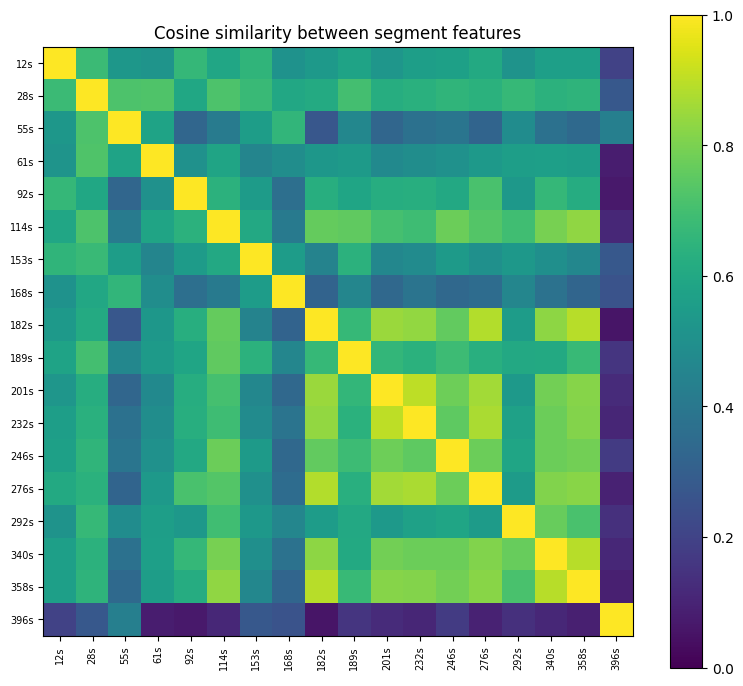

In [6]:
# L2-normalize before computing cosine similarity
norms = np.linalg.norm(features, axis=1, keepdims=True)
feats_norm = features / np.clip(norms, 1e-8, None)
sim_matrix = feats_norm @ feats_norm.T  # cosine similarity

labels = [f'{s:.0f}s' for s in start_secs]

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(sim_matrix, vmin=0, vmax=1, cmap='viridis')
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set_yticklabels(labels, fontsize=7)
ax.set_title('Cosine similarity between segment features')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 6. Show frames from most and least similar segment pairs

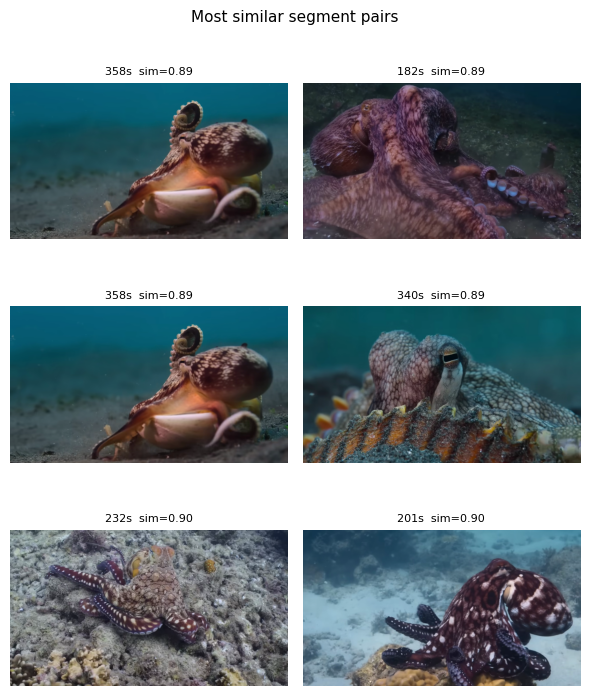

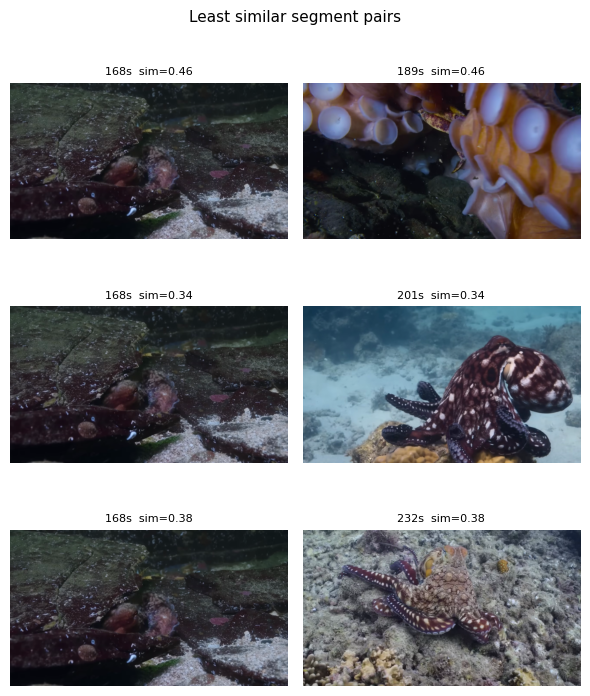

In [7]:
def get_center_frame(video_path, start_sec, end_sec):
    mid = (start_sec + end_sec) / 2
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(mid * fps))
    ret, frame = cap.read()
    cap.release()
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) if ret else None

# mask diagonal and upper triangle
mask = np.triu(np.ones_like(sim_matrix, dtype=bool))
sim_lower = np.where(mask, -1, sim_matrix)

# top-3 most similar pairs
top_idx = np.dstack(np.unravel_index(np.argsort(sim_lower.ravel())[-3:], sim_matrix.shape))[0]
# top-3 least similar pairs
low_idx = np.dstack(np.unravel_index(np.argsort(sim_lower.ravel())[3:6], sim_matrix.shape))[0]

def show_pairs(pairs, title):
    fig, axes = plt.subplots(len(pairs), 2, figsize=(6, 2.5 * len(pairs)))
    fig.suptitle(title, fontsize=11)
    for row, (i, j) in enumerate(pairs):
        for col, idx in enumerate([i, j]):
            frame = get_center_frame(VIDEO_PATH, start_secs[idx], end_secs[idx])
            if frame is not None:
                axes[row][col].imshow(frame)
            axes[row][col].set_title(
                f'{start_secs[idx]:.0f}s  sim={sim_matrix[i,j]:.2f}', fontsize=8)
            axes[row][col].axis('off')
    plt.tight_layout()
    plt.show()

show_pairs(top_idx, 'Most similar segment pairs')
show_pairs(low_idx, 'Least similar segment pairs')